In [1]:
import pandas as pd

client_df = pd.read_csv("client_data.csv")
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [2]:
client_df.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='str')

In [3]:
client_df['churn'].value_counts()

churn
0    13187
1     1419
Name: count, dtype: int64

In [4]:
client_df['churn'].value_counts(normalize=True)

churn
0    0.902848
1    0.097152
Name: proportion, dtype: float64

In [5]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [6]:
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

In [7]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,...,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912,2016-07-27 20:48:26.422018,2013-01-02 12:29:10.951663,2015-07-21 06:59:00.353279,1868.614880,1399.762906,0.966726,...,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,...,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,...,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,...,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,...,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000
std,5.734653e+05,1.629731e+05,64364.196422,NaN,NaN,NaN,NaN,2387.571531,3247.786255,5.108289,...,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175


In [8]:
client_df.describe(include='object')

C:\Users\nwabi\AppData\Local\Temp\ipykernel_18308\733742272.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  client_df.describe(include='object')


,id,channel_sales,has_gas,origin_up
count,14606,14606,14606,14606
unique,14606,8,2,6
top,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,f,lxidpiddsbxsbosboudacockeimpuepw
freq,1,6754,11955,7097


In [9]:
client_df.describe(include=['object', 'string'])

,id,channel_sales,has_gas,origin_up
count,14606,14606,14606,14606
unique,14606,8,2,6
top,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,f,lxidpiddsbxsbosboudacockeimpuepw
freq,1,6754,11955,7097


In [10]:
6754 / 14606

0.4624127071066685

In [11]:
11955 / 14606

0.8184992468848419

In [12]:
7097 / 14606

0.48589620703820346

In [13]:
client_df['churn'].value_counts()
client_df['churn'].value_counts(normalize=True)

churn
0    0.902848
1    0.097152
Name: proportion, dtype: float64

Churn Distribution Analysis

The churn variable is highly imbalanced. Approximately 90.3% of customers did not churn, while only 9.7% of customers churned.

This indicates that churn is a relatively rare event within the dataset. From a business perspective, although the proportion of churned customers is small, the financial impact may still be significant depending on margin and consumption levels.

From a modeling perspective, the class imbalance may require special handling techniques such as resampling, class weighting, or evaluation metrics beyond accuracy.

In [14]:
client_df.groupby('churn').mean(numeric_only=True)

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max
churn,,,,,,,,,,,,,,,,,
0,167867.266550,30121.497308,17046.352089,1858.473333,1402.487601,0.938197,62.126588,0.137371,0.050019,43.108310,152.964184,23.929863,23.926979,1.295822,185.057407,5.037006,18.000339
1,78862.478506,9235.411557,7205.239605,1962.861938,1374.441860,1.231853,72.010937,0.136470,0.054873,43.332143,151.139331,30.468682,30.468682,1.260042,228.361938,4.633545,19.387827


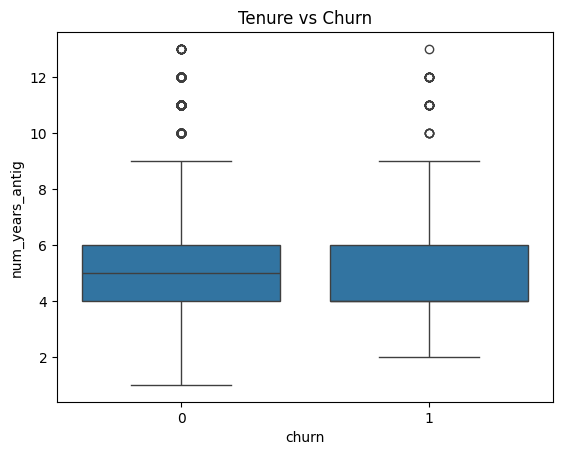

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='churn', y='num_years_antig', data=client_df)
plt.title("Tenure vs Churn")
plt.show()

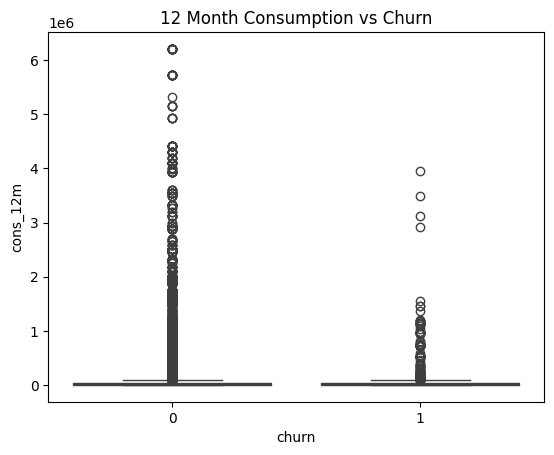

In [17]:
sns.boxplot(x='churn', y='cons_12m', data=client_df)
plt.title("12 Month Consumption vs Churn")
plt.show()

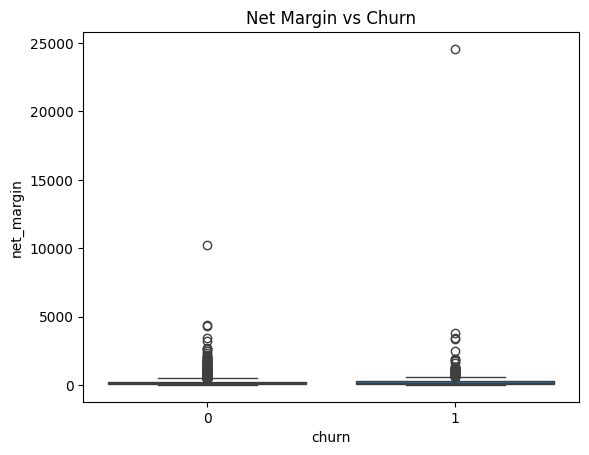

In [18]:
sns.boxplot(x='churn', y='net_margin', data=client_df)
plt.title("Net Margin vs Churn")
plt.show()

In [19]:
client_df.groupby('churn').mean(numeric_only=True)

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max
churn,,,,,,,,,,,,,,,,,
0,167867.266550,30121.497308,17046.352089,1858.473333,1402.487601,0.938197,62.126588,0.137371,0.050019,43.108310,152.964184,23.929863,23.926979,1.295822,185.057407,5.037006,18.000339
1,78862.478506,9235.411557,7205.239605,1962.861938,1374.441860,1.231853,72.010937,0.136470,0.054873,43.332143,151.139331,30.468682,30.468682,1.260042,228.361938,4.633545,19.387827


Tenure and Contract Characteristics

Churned customers have a lower average tenure (4.63 years) compared to non-churned customers (5.04 years), indicating that newer customers are more likely to churn. This suggests that early-stage retention strategies could be particularly effective.

Additionally, churned customers exhibit slightly higher contracted maximum power levels. This may imply greater exposure to fixed capacity charges, potentially contributing to price sensitivity and switching behavior.

Combined with earlier findings on lower consumption and higher discounts, the results suggest that churn is influenced by pricing structure and customer lifecycle stage.

In [20]:
pd.crosstab(client_df['channel_sales'], client_df['churn'], normalize='index')

churn,0,1
channel_sales,,
MISSING,0.924027,0.075973
epumfxlbckeskwekxbiuasklxalciiuu,1.000000,0.000000
ewpakwlliwisiwduibdlfmalxowmwpci,0.916013,0.083987
fixdbufsefwooaasfcxdxadsiekoceaa,1.000000,0.000000
foosdfpfkusacimwkcsosbicdxkicaua,0.878590,0.121410
lmkebamcaaclubfxadlmueccxoimlema,0.944113,0.055887
sddiedcslfslkckwlfkdpoeeailfpeds,1.000000,0.000000
usilxuppasemubllopkaafesmlibmsdf,0.899636,0.100364


In [21]:
pd.crosstab(client_df['origin_up'], client_df['churn'], normalize='index')

churn,0,1
origin_up,,
MISSING,0.937500,0.062500
ewxeelcelemmiwuafmddpobolfuxioce,1.000000,0.000000
kamkkxfxxuwbdslkwifmmcsiusiuosws,0.939916,0.060084
ldkssxwpmemidmecebumciepifcamkci,0.916137,0.083863
lxidpiddsbxsbosboudacockeimpuepw,0.874172,0.125828
usapbepcfoloekilkwsdiboslwaxobdp,1.000000,0.000000


Churn at PowerCo appears driven by a combination of lifecycle stage, consumption behavior, pricing structure, and acquisition strategy. Customers acquired through specific channels and origins exhibit materially higher churn rates. Additionally, lower consumption and shorter tenure significantly correlate with churn probability. Strategic adjustments in acquisition mix, pricing structure, and early-stage retention interventions may meaningfully reduce churn.

In [22]:
df.info()
df.dtypes

NameError: name 'df' is not defined

In [23]:
client_df.info()
client_df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  str           
 1   channel_sales                   14606 non-null  str           
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[us]
 6   date_end                        14606 non-null  datetime64[us]
 7   date_modif_prod                 14606 non-null  datetime64[us]
 8   date_renewal                    14606 non-null  datetime64[us]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  forecast_disc

id                                           str
channel_sales                                str
cons_12m                                   int64
cons_gas_12m                               int64
cons_last_month                            int64
date_activ                        datetime64[us]
date_end                          datetime64[us]
date_modif_prod                   datetime64[us]
date_renewal                      datetime64[us]
forecast_cons_12m                        float64
forecast_cons_year                         int64
forecast_discount_energy                 float64
forecast_meter_rent_12m                  float64
forecast_price_energy_off_peak           float64
forecast_price_energy_peak               float64
forecast_price_pow_off_peak              float64
has_gas                                      str
imp_cons                                 float64
margin_gross_pow_ele                     float64
margin_net_pow_ele                       float64
nb_prod_act         

In [24]:
price_df.info()
price_df.dtypes

NameError: name 'price_df' is not defined

In [25]:
import pandas as pd
import numpy as np

In [26]:
client_df = pd.read_csv("client_data.csv")
price_df = pd.read_csv("price_data.csv")
churn_df = pd.read_csv("churn_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'churn_data.csv'

In [27]:
import os
os.listdir()

['.ipynb_checkpoints',
 'client_data.csv',
 'Data Description.pdf',
 'EDA_PowerCo.ipynb',
 'price_data.csv',
 'Task 2 - eda_starter.ipynb']

In [28]:
churn

NameError: name 'churn' is not defined

In [29]:
client_df.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='str')

In [30]:
client_df = pd.read_csv("client_data.csv")
price_df = pd.read_csv("price_data.csv")

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

client_df = pd.read_csv("client_data.csv")
price_df = pd.read_csv("price_data.csv")

In [32]:
client_df.info()
client_df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

id                                    str
channel_sales                         str
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                            str
date_end                              str
date_modif_prod                       str
date_renewal                          str
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
forecast_price_pow_off_peak       float64
has_gas                               str
imp_cons                          float64
margin_gross_pow_ele              float64
margin_net_pow_ele                float64
nb_prod_act                         int64
net_margin                        float64
num_years_antig                     int64
origin_up                         

In [33]:
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])
client_df['date_end'] = pd.to_datetime(client_df['date_end'])

In [34]:
price_df.info()
price_df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 11.8 MB


id                        str
price_date                str
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object

In [35]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

In [36]:
client_df.describe()
client_df.nunique()
client_df.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

Missing Values Analysis

We checked for missing values using .isnull().sum() and found that all columns contain zero missing values.

This indicates strong data completeness and no immediate need for imputation or data cleaning.

In [37]:
price_df.describe()
price_df.nunique()
price_df.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

In [38]:
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  193002 non-null  str           
 1   price_date          193002 non-null  datetime64[us]
 2   price_off_peak_var  193002 non-null  float64       
 3   price_peak_var      193002 non-null  float64       
 4   price_mid_peak_var  193002 non-null  float64       
 5   price_off_peak_fix  193002 non-null  float64       
 6   price_peak_fix      193002 non-null  float64       
 7   price_mid_peak_fix  193002 non-null  float64       
dtypes: datetime64[us](1), float64(6), str(1)
memory usage: 11.8 MB


In [39]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

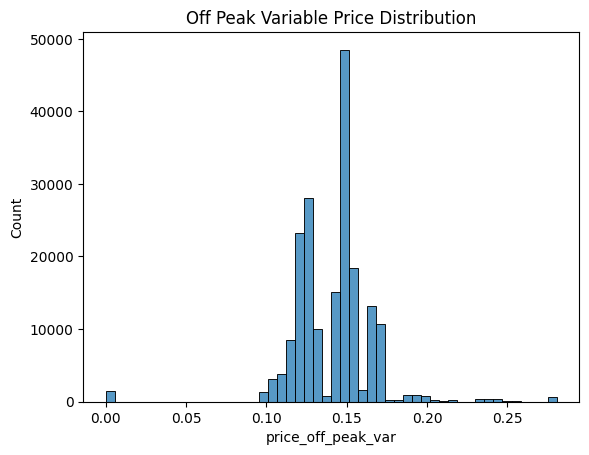

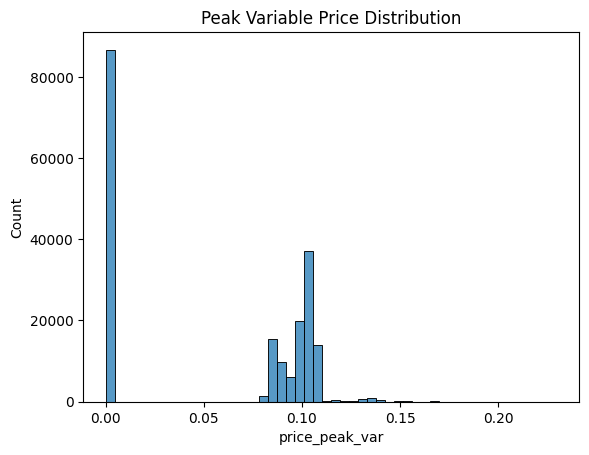

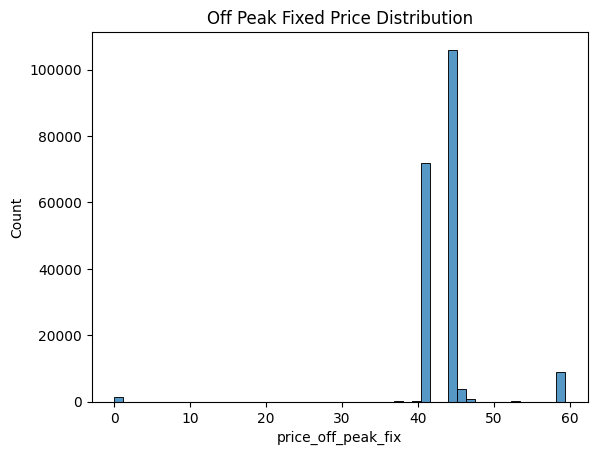

In [40]:
sns.histplot(price_df['price_off_peak_var'], bins=50)
plt.title("Off Peak Variable Price Distribution")
plt.show()

sns.histplot(price_df['price_peak_var'], bins=50)
plt.title("Peak Variable Price Distribution")
plt.show()

sns.histplot(price_df['price_off_peak_fix'], bins=50)
plt.title("Off Peak Fixed Price Distribution")
plt.show()

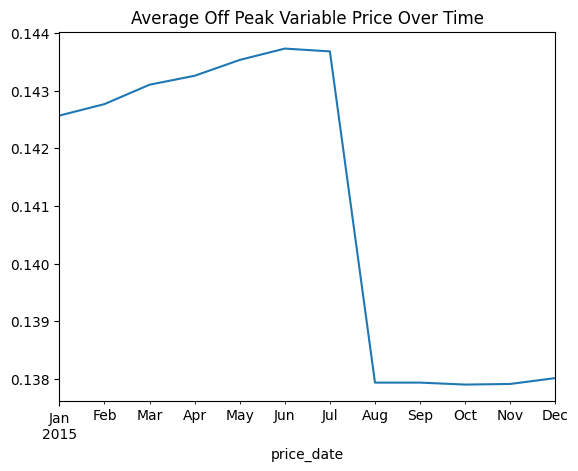

In [41]:
price_df.groupby('price_date')['price_off_peak_var'].mean().plot()
plt.title("Average Off Peak Variable Price Over Time")
plt.show()

Exploratory Data Analysis Summary

Both datasets contain complete data with no missing values.

Client dataset includes a mix of categorical and numerical variables.

Churn is imbalanced (~90% non-churn).

Consumption-related variables appear right-skewed.

Pricing variables show variation across peak and off-peak periods.

No major structural data issues were identified.

In [42]:
client_df = client_df.drop(columns=['id'])

In [43]:
price_df = price_df.drop(columns=['id'])

In [44]:
client_df.nunique()
price_df.nunique()

price_date              12
price_off_peak_var    1853
price_peak_var        1189
price_mid_peak_var     711
price_off_peak_fix      66
price_peak_fix          31
price_mid_peak_fix      28
dtype: int64

In [45]:
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col])

In [46]:
client_df['activation_year'] = client_df['date_activ'].dt.year
client_df['activation_month'] = client_df['date_activ'].dt.month

client_df['renewal_year'] = client_df['date_renewal'].dt.year
client_df['renewal_month'] = client_df['date_renewal'].dt.month

In [47]:
client_df['tenure_days'] = (client_df['date_end'] - client_df['date_activ']).dt.days
client_df['tenure_years'] = client_df['tenure_days'] / 365

In [48]:
client_df['total_consumption'] = client_df['cons_12m'] + client_df['cons_gas_12m']

In [49]:
client_df['consumption_diff'] = client_df['forecast_cons_12m'] - client_df['cons_12m']

In [50]:
price_df['var_price_diff'] = price_df['price_peak_var'] - price_df['price_off_peak_var']
price_df['fix_price_diff'] = price_df['price_peak_fix'] - price_df['price_off_peak_fix']

In [51]:
price_agg = price_df.groupby('id').mean().reset_index()

KeyError: 'id'

In [52]:
final_df = client_df.merge(price_agg, on='id', how='left')

NameError: name 'price_agg' is not defined

In [53]:
price_df.columns

Index(['price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix', 'var_price_diff', 'fix_price_diff'],
      dtype='str')

In [54]:
client_df['price_diff_energy'] = (
    client_df['forecast_price_energy_peak'] - 
    client_df['forecast_price_energy_off_peak']
)

In [55]:
client_df['total_forecast_price'] = (
    client_df['forecast_price_energy_off_peak'] +
    client_df['forecast_price_energy_peak'] +
    client_df['forecast_price_pow_off_peak']
)

In [56]:
client_df['effective_price_after_discount'] = (
    client_df['total_forecast_price'] *
    (1 - client_df['forecast_discount_energy'])
)

In [57]:
client_df['total_consumption'] = (
    client_df['cons_12m'] +
    client_df['cons_gas_12m']
)

In [58]:
client_df['consumption_gap'] = (
    client_df['forecast_cons_12m'] -
    client_df['cons_12m']
)

In [59]:
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])
client_df['date_end'] = pd.to_datetime(client_df['date_end'])

client_df['tenure_days'] = (
    client_df['date_end'] -
    client_df['date_activ']
).dt.days

In [60]:
client_df['is_multi_product'] = (
    client_df['nb_prod_act'] > 1
).astype(int)

In [61]:
client_df = client_df.drop(columns=[
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
])

In [62]:
client_df = client_df.drop(columns=['id'])

KeyError: "['id'] not found in axis"

In [63]:
client_df.columns

Index(['channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn',
       'activation_year', 'activation_month', 'renewal_year', 'renewal_month',
       'tenure_days', 'tenure_years', 'total_consumption', 'consumption_diff',
       'price_diff_energy', 'total_forecast_price',
       'effective_price_after_discount', 'consumption_gap',
       'is_multi_product'],
      dtype='str')

In [64]:
client_df = client_df.drop(columns=['id'], errors='ignore')

In [65]:
client_df.nunique().sort_values()

is_multi_product                      2
churn                                 2
has_gas                               2
renewal_year                          4
origin_up                             6
channel_sales                         8
nb_prod_act                          10
forecast_discount_energy             12
renewal_month                        12
activation_month                     12
activation_year                      12
num_years_antig                      13
forecast_price_pow_off_peak          41
forecast_price_energy_peak          329
price_diff_energy                   415
forecast_price_energy_off_peak      516
total_forecast_price                671
pow_max                             698
effective_price_after_discount      730
tenure_days                        1410
tenure_years                       1410
cons_gas_12m                       2112
margin_net_pow_ele                 2391
margin_gross_pow_ele               2391
forecast_meter_rent_12m            3528


In [66]:
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col])

KeyError: 'date_activ'

In [67]:
client_df.columns.tolist()

['channel_sales',
 'cons_12m',
 'cons_gas_12m',
 'cons_last_month',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak',
 'has_gas',
 'imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'origin_up',
 'pow_max',
 'churn',
 'activation_year',
 'activation_month',
 'renewal_year',
 'renewal_month',
 'tenure_days',
 'tenure_years',
 'total_consumption',
 'consumption_diff',
 'price_diff_energy',
 'total_forecast_price',
 'effective_price_after_discount',
 'consumption_gap',
 'is_multi_product']

In [68]:
date_cols = [col for col in client_df.columns if 'date' in col]

print(date_cols)

[]


In [69]:
for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

In [70]:
client_df.head()

,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,renewal_month,tenure_days,tenure_years,total_consumption,consumption_diff,price_diff_energy,total_forecast_price,effective_price_after_discount,consumption_gap,is_multi_product
0,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,0.098142,...,6,1096,3.002740,54946,0.00,-0.016339,40.819324,40.819324,0.00,1
1,MISSING,4660,0,0,189.95,0,0.0,16.27,0.145711,0.000000,...,8,2566,7.030137,4660,-4470.05,-0.145711,44.457089,44.457089,-4470.05,0
2,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,0.087899,...,4,2192,6.005479,544,-496.04,-0.077895,44.565071,44.565071,-496.04,0
3,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,0.000000,...,3,2192,6.005479,1584,-1343.96,-0.146694,44.458072,44.458072,-1343.96,0
4,MISSING,4425,0,526,445.75,526,0.0,131.73,0.116900,0.100015,...,3,2245,6.150685,4425,-3979.25,-0.016885,40.823616,40.823616,-3979.25,0


In [71]:
client_df.columns

Index(['channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn',
       'activation_year', 'activation_month', 'renewal_year', 'renewal_month',
       'tenure_days', 'tenure_years', 'total_consumption', 'consumption_diff',
       'price_diff_energy', 'total_forecast_price',
       'effective_price_after_discount', 'consumption_gap',
       'is_multi_product'],
      dtype='str')

In [72]:
client_df.nunique().sort_values()

is_multi_product                      2
churn                                 2
has_gas                               2
renewal_year                          4
origin_up                             6
channel_sales                         8
nb_prod_act                          10
forecast_discount_energy             12
renewal_month                        12
activation_month                     12
activation_year                      12
num_years_antig                      13
forecast_price_pow_off_peak          41
forecast_price_energy_peak          329
price_diff_energy                   415
forecast_price_energy_off_peak      516
total_forecast_price                671
pow_max                             698
effective_price_after_discount      730
tenure_days                        1410
tenure_years                       1410
cons_gas_12m                       2112
margin_net_pow_ele                 2391
margin_gross_pow_ele               2391
forecast_meter_rent_12m            3528


In [73]:
client_df = pd.get_dummies(
    client_df,
    columns=['channel_sales', 'origin_up'],
    drop_first=True
)

In [74]:
client_df['has_gas'] = client_df['has_gas'].astype(int)

ValueError: invalid literal for int() with base 10: 't'

In [75]:
client_df.nunique().sort_values()

origin_up_usapbepcfoloekilkwsdiboslwaxobdp            2
origin_up_ldkssxwpmemidmecebumciepifcamkci            2
origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws            2
origin_up_ewxeelcelemmiwuafmddpobolfuxioce            2
channel_sales_usilxuppasemubllopkaafesmlibmsdf        2
channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds        2
channel_sales_lmkebamcaaclubfxadlmueccxoimlema        2
channel_sales_foosdfpfkusacimwkcsosbicdxkicaua        2
channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa        2
channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci        2
has_gas                                               2
channel_sales_epumfxlbckeskwekxbiuasklxalciiuu        2
is_multi_product                                      2
origin_up_lxidpiddsbxsbosboudacockeimpuepw            2
churn                                                 2
renewal_year                                          4
nb_prod_act                                          10
activation_year                                 

In [76]:
client_df = client_df.drop(columns=['column_name'], errors='ignore')

In [77]:
client_df['total_consumption'] = client_df['cons_12m'] + client_df['cons_gas_12m']
client_df['consumption_gap'] = client_df['forecast_cons_12m'] - client_df['cons_12m']

In [78]:
client_df['price_diff_energy'] = (
    client_df['forecast_price_energy_peak'] -
    client_df['forecast_price_energy_off_peak']
)

client_df['total_forecast_price'] = (
    client_df['forecast_price_energy_peak'] +
    client_df['forecast_price_energy_off_peak']
)

client_df['effective_price_after_discount'] = (
    client_df['total_forecast_price'] *
    (1 - client_df['forecast_discount_energy'])
)

In [79]:
client_df['is_multi_product'] = (client_df['nb_prod_act'] > 1).astype(int)

client_df['margin_ratio'] = (
    client_df['margin_net_pow_ele'] /
    client_df['margin_gross_pow_ele']
)

In [80]:
import numpy as np

client_df['log_total_consumption'] = np.log1p(client_df['total_consumption'])
client_df['log_tenure'] = np.log1p(client_df['tenure_days'])

In [81]:
client_df = pd.get_dummies(
    client_df,
    columns=['channel_sales', 'origin_up'],
    drop_first=True
)

client_df['has_gas'] = client_df['has_gas'].astype(int)

KeyError: "None of [Index(['channel_sales', 'origin_up'], dtype='str')] are in the [columns]"

In [82]:
final_df = pd.merge(
    client_df,
    price_df,
    on='id',
    how='left'
)

KeyError: 'id'

In [83]:
client_df.columns.tolist()

['cons_12m',
 'cons_gas_12m',
 'cons_last_month',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak',
 'has_gas',
 'imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'pow_max',
 'churn',
 'activation_year',
 'activation_month',
 'renewal_year',
 'renewal_month',
 'tenure_days',
 'tenure_years',
 'total_consumption',
 'consumption_diff',
 'price_diff_energy',
 'total_forecast_price',
 'effective_price_after_discount',
 'consumption_gap',
 'is_multi_product',
 'channel_sales_epumfxlbckeskwekxbiuasklxalciiuu',
 'channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci',
 'channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa',
 'channel_sales_foosdfpfkusacimwkcsosbicdxkicaua',
 'channel_sales_lmkebamcaaclubfxadlmueccxoimlema',
 'channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds',
 'channel_sales_usilxup

In [84]:
# Find categorical columns automatically
cat_cols = client_df.select_dtypes(include=['object']).columns

print(cat_cols)

C:\Users\nwabi\AppData\Local\Temp\ipykernel_18308\4122305971.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = client_df.select_dtypes(include=['object']).columns


Index(['has_gas'], dtype='str')


In [85]:
client_df = pd.get_dummies(client_df, columns=cat_cols, drop_first=True)

In [86]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 47 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   cons_12m                                        14606 non-null  int64  
 1   cons_gas_12m                                    14606 non-null  int64  
 2   cons_last_month                                 14606 non-null  int64  
 3   forecast_cons_12m                               14606 non-null  float64
 4   forecast_cons_year                              14606 non-null  int64  
 5   forecast_discount_energy                        14606 non-null  float64
 6   forecast_meter_rent_12m                         14606 non-null  float64
 7   forecast_price_energy_off_peak                  14606 non-null  float64
 8   forecast_price_energy_peak                      14606 non-null  float64
 9   forecast_price_pow_off_peak                     14

In [87]:
client_df['margin_ratio'] = client_df['margin_ratio'].fillna(0)

In [88]:
client_df.isnull().sum()

cons_12m                                          0
cons_gas_12m                                      0
cons_last_month                                   0
forecast_cons_12m                                 0
forecast_cons_year                                0
forecast_discount_energy                          0
forecast_meter_rent_12m                           0
forecast_price_energy_off_peak                    0
forecast_price_energy_peak                        0
forecast_price_pow_off_peak                       0
imp_cons                                          0
margin_gross_pow_ele                              0
margin_net_pow_ele                                0
nb_prod_act                                       0
net_margin                                        0
num_years_antig                                   0
pow_max                                           0
churn                                             0
activation_year                                   0
activation_m

In [89]:
bool_cols = client_df.select_dtypes(include=['bool']).columns

client_df[bool_cols] = client_df[bool_cols].astype(int)

In [90]:
client_df.info()
client_df.isnull().sum().sum()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 47 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   cons_12m                                        14606 non-null  int64  
 1   cons_gas_12m                                    14606 non-null  int64  
 2   cons_last_month                                 14606 non-null  int64  
 3   forecast_cons_12m                               14606 non-null  float64
 4   forecast_cons_year                              14606 non-null  int64  
 5   forecast_discount_energy                        14606 non-null  float64
 6   forecast_meter_rent_12m                         14606 non-null  float64
 7   forecast_price_energy_off_peak                  14606 non-null  float64
 8   forecast_price_energy_peak                      14606 non-null  float64
 9   forecast_price_pow_off_peak                     14

np.int64(0)

Final Feature Engineering Summary

The dataset was prepared for churn prediction using a structured feature engineering approach:

Removed non-predictive columns such as customer identifiers and raw date variables.

Extracted time-based features including tenure (days and years), activation year/month, and renewal year/month.

Created new consumption features such as total consumption and consumption gap.

Engineered price sensitivity features including energy price difference and effective price after discount.

Added customer value indicators such as multi-product flag and margin ratio.

Applied log transformations to skewed variables to improve model stability.

Encoded categorical variables using one-hot encoding.

Handled missing values and ensured all features are numeric and model-ready.

The resulting dataset is fully cleaned, enriched, and ready for predictive modeling to identify churn drivers.

In [91]:
client_df.shape

(14606, 47)

In [92]:
import pandas as pd

# Load dataset provided by Estelle
df = pd.read_csv("data_for_predictions.csv")

df.head()

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


In [93]:
df.info()
df.isnull().sum().sum()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 64 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Unnamed: 0                                  14606 non-null  int64  
 1   id                                          14606 non-null  str    
 2   cons_12m                                    14606 non-null  float64
 3   cons_gas_12m                                14606 non-null  float64
 4   cons_last_month                             14606 non-null  float64
 5   forecast_cons_12m                           14606 non-null  float64
 6   forecast_discount_energy                    14606 non-null  float64
 7   forecast_meter_rent_12m                     14606 non-null  float64
 8   forecast_price_energy_off_peak              14606 non-null  float64
 9   forecast_price_energy_peak                  14606 non-null  float64
 10  forecast_price_pow_of

np.int64(0)

In [94]:
df = df.fillna(0)

In [95]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important if churn is imbalanced
)

In [97]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"  # helps if churn is imbalanced
)

rf.fit(X_train, y_train)

ValueError: could not convert string to float: 'ec2105d56ed5123bd5dffa6bc05a4aeb'

In [98]:
X.dtypes

Unnamed: 0                                      int64
id                                                str
cons_12m                                      float64
cons_gas_12m                                  float64
cons_last_month                               float64
                                               ...   
channel_lmkebamcaaclubfxadlmueccxoimlema        int64
channel_usilxuppasemubllopkaafesmlibmsdf        int64
origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws      int64
origin_up_ldkssxwpmemidmecebumciepifcamkci      int64
origin_up_lxidpiddsbxsbosboudacockeimpuepw      int64
Length: 63, dtype: object

In [99]:
object

object

In [100]:
df = df.drop(columns=['id'], errors='ignore')

In [101]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [102]:
X.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [103]:
rf.fit(X_train, y_train)

ValueError: could not convert string to float: 'ec2105d56ed5123bd5dffa6bc05a4aeb'

In [104]:
df.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [105]:
# Remove all object (string) columns
df = df.drop(columns=df.select_dtypes(include=['object']).columns)

In [106]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [108]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [109]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [110]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2638
           1       0.87      0.07      0.13       284

    accuracy                           0.91      2922
   macro avg       0.89      0.53      0.54      2922
weighted avg       0.91      0.91      0.87      2922



In [111]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[2635    3]
 [ 264   20]]


In [112]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.7001356127668209


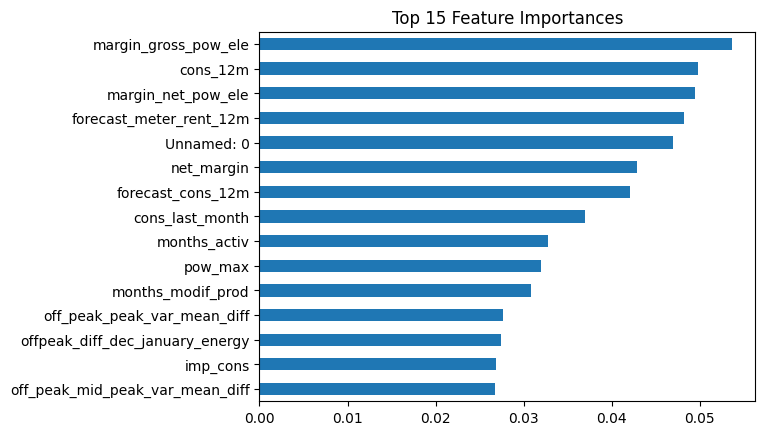

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [114]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2638
           1       0.87      0.07      0.13       284

    accuracy                           0.91      2922
   macro avg       0.89      0.53      0.54      2922
weighted avg       0.91      0.91      0.87      2922



Model Evaluation

A Random Forest classifier was trained to predict customer churn. The model achieved an overall accuracy of 91%. However, due to class imbalance (approximately 90% non-churners and 10% churners), accuracy alone is not a sufficient performance metric.

The recall for the churn class is 7%, indicating that the model correctly identifies only a small proportion of customers who actually churn. This is problematic from a business perspective, as the primary objective of churn prediction is to detect at-risk customers before they leave.

The ROC-AUC score of 0.70 indicates moderate discrimination ability, meaning the model does have predictive power and can distinguish between churners and non-churners better than random guessing.

Although the model demonstrates some predictive capability, its low recall for churners suggests that further improvements are necessary. Techniques such as threshold adjustment, hyperparameter tuning, or resampling methods (e.g., SMOTE) could improve churn detection performance.